In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import importlib
import torch
import model.transformer
import model.data as data
import model.constants as constants
import time
import matplotlib.pyplot as plt
from IPython.display import display
importlib.reload(constants)
importlib.reload(model.transformer)
importlib.reload(data)
print("START: ", time.perf_counter())
if constants.DEBUG: print("Start of file", time.perf_counter())
transformer = model.transformer.Transformer()
if constants.DEBUG: print("Transform made", time.perf_counter())
dev_cutoff = int(0.9 * len(data.full_text)) # TODO add test split
train_data = data.full_text[:dev_cutoff]
dev_data = data.full_text[dev_cutoff:]
X_batch, Y_batch = data.GetRandomBatch(train_data)

START:  67950.143725791


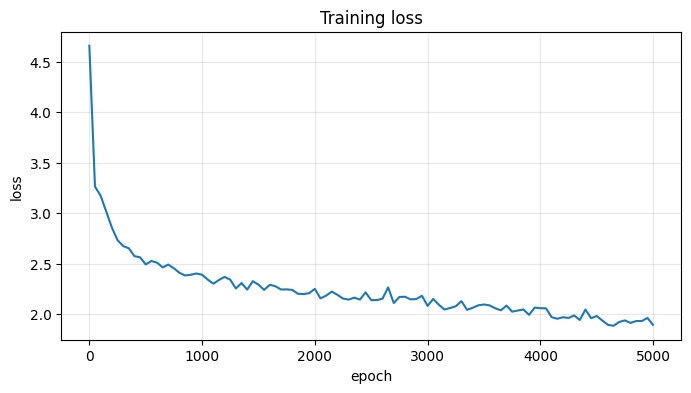

loss: 4.658349990844727


loss: 3.2638890743255615


loss: 3.173771619796753


loss: 3.0165369510650635


loss: 2.8578197956085205


...

loss: 1.9142740964889526


loss: 1.9329259395599365


loss: 1.932987928390503


loss: 1.963310718536377


loss: 1.8953877687454224


In [3]:

loss_steps = []
loss_history = []
plot_every = max(1, constants.EPOCHS // 100)

fig, ax = plt.subplots(figsize=(8, 4))
(loss_line,) = ax.plot([], [])
ax.set_xlabel("epoch")
ax.set_ylabel("loss")
ax.set_title("Training loss")
ax.grid(True, alpha=0.3)
plot_handle = display(fig, display_id=True)

for i in range(constants.EPOCHS):
    if constants.DEBUG: print("Start", time.perf_counter())
    X_batch, Y_batch = data.GetRandomBatch(train_data);
    if constants.DEBUG: print("Got batches", time.perf_counter())
    out = transformer.forward(X_batch)
    if constants.DEBUG: print("Forwad complete", time.perf_counter())
    B, T, C = out.shape
    loss = transformer.backward(out.view(B*T, C), Y_batch.view(B*T))
    if constants.DEBUG: print("Backward complete", time.perf_counter())
    if (i % plot_every == 0) or (i == constants.EPOCHS - 1):
        print(f"loss: {loss}")
        loss_steps.append(i)
        loss_history.append(loss)
        loss_line.set_data(loss_steps, loss_history)
        ax.relim()
        ax.autoscale_view()
        if plot_handle is not None:
            plot_handle.update(fig)
        else:
            fig.canvas.draw_idle()
            plt.pause(0.001)

plt.close(fig)

In [4]:
def DecodeTokenList(token_list):
    return data.decode(token_list)


def TestModel(transformer, data_source, n_tokens=10):
    X_test, _ = data.GetRandomBatch(data_source)
    # X_test = X_batch
    context = X_test[0].clone()
    start_context = context.clone()

    print("START:")
    print(DecodeTokenList(context))

    generated_tokens = []

    for i in range(n_tokens):
        # Add fake batch dimension: [T] -> [1, T]
        context_batch = context.view(1, constants.CONTEXT_WINDOW_SIZE)

        # Your transformer currently expects N_BATCHES exactly,
        # so repeat the same context N_BATCHES times.
        context_batch = context_batch.repeat(constants.N_BATCHES, 1)

        # Predict next token from the final position in the first batch row
        with torch.no_grad():
            logits = transformer.forward(context_batch)
        pred = logits[0, -1].argmax(dim=-1)

        generated_tokens.append(pred)

        # Slide context window left and append prediction
        context = torch.cat([context[1:], pred.view(1)], dim=0)

    print("\nGENERATED:")
    print(DecodeTokenList(generated_tokens))

    print("\nFULL:")
    print(DecodeTokenList(start_context) + DecodeTokenList(generated_tokens))

TestModel(transformer, train_data, n_tokens=100)

START:
wel in a ten-times-barr'd-up che

GENERATED:


 the the the the the the the the the the the the the the the the the the the the the the the the the

FULL:


wel in a ten-times-barr'd-up che the the the the the the the the the the the the the the the the the the the the the the the the the


In [5]:
def ModelContextWindowSize(transformer):
    return transformer.positional_encoding.shape[0]


def EncodeFixedContext(text, context_window_size):
    tokens = data.encode(text)
    if len(tokens) < context_window_size:
        pad_token = data.tokenizer_map[' ']
        tokens = [pad_token] * (context_window_size - len(tokens)) + tokens
    else:
        tokens = tokens[-context_window_size:]
    return torch.tensor(tokens, dtype=torch.int64, device=model.shared.device)


@torch.no_grad()
def ForwardSingleContext(transformer, context_tokens):
    context_window_size = ModelContextWindowSize(transformer)
    context_batch = context_tokens.view(1, context_window_size)
    context_batch = context_batch.repeat(constants.N_BATCHES, 1)

    old_context_window_size = constants.CONTEXT_WINDOW_SIZE
    constants.CONTEXT_WINDOW_SIZE = context_window_size
    try:
        logits = transformer.forward(context_batch)
    finally:
        constants.CONTEXT_WINDOW_SIZE = old_context_window_size

    return logits[0, -1, :]


def ShowTopProbs(name, probs, top_k):
    values, indices = probs.topk(top_k)
    print(name)
    for value, index in zip(values, indices):
        ch = data.untokenizer_map[int(index)]
        print(f"  {repr(ch):>6}  {float(value):.4f}")


def CompareContexts(transformer, text1, text2, top_k=10):
    context_window_size = ModelContextWindowSize(transformer)
    ctx1 = EncodeFixedContext(text1, context_window_size)
    ctx2 = EncodeFixedContext(text2, context_window_size)

    logits1 = ForwardSingleContext(transformer, ctx1)
    logits2 = ForwardSingleContext(transformer, ctx2)

    probs1 = torch.softmax(logits1, dim=-1)
    probs2 = torch.softmax(logits2, dim=-1)

    print("CTX 1:", repr(data.decode(ctx1)))
    print("CTX 2:", repr(data.decode(ctx2)))
    print()
    print("max abs logit diff:", (logits1 - logits2).abs().max().item())
    print("mean abs logit diff:", (logits1 - logits2).abs().mean().item())
    print("max abs prob diff:", (probs1 - probs2).abs().max().item())
    print()

    ShowTopProbs("top ctx1:", probs1, top_k)
    print()
    ShowTopProbs("top ctx2:", probs2, top_k)


CompareContexts(
    transformer,
    "To be, or not to be, that is",
    "zzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzz",
)

CompareContexts(
    transformer,
    "wel in a ten-times-barr'd-up che",
    "xxxxxxxxxxxxxxxxxxxxxxxxxxxxx che",
)

CompareContexts(
    transformer,
    "aaaaaaaaaaaaaaaaaaaaaaaaaaaa the ",
    "bbbbbbbbbbbbbbbbbbbbbbbbbbbb the ",
)


CTX 1: '    To be, or not to be, that is'
CTX 2: 'zzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzz'

max abs logit diff: 6.39470911026001
mean abs logit diff: 2.4751150608062744
max abs prob diff: 0.8630836606025696

top ctx1:
     ' '  0.8754
     ','  0.0297
    '\n'  0.0181
     'h'  0.0159
     't'  0.0127
     '.'  0.0101
     ':'  0.0060
     's'  0.0059
     "'"  0.0037
     ';'  0.0032

top ctx2:
     'e'  0.6963
     'i'  0.1051
     'a'  0.0645
     'o'  0.0392
     'y'  0.0303
     ' '  0.0123
     'n'  0.0091
     'h'  0.0072
     'u'  0.0059
     ','  0.0043
CTX 1: "wel in a ten-times-barr'd-up che"
CTX 2: 'xxxxxxxxxxxxxxxxxxxxxxxxxxxx che'

max abs logit diff: 0.4567606449127197
mean abs logit diff: 0.16386595368385315
max abs prob diff: 0.013129472732543945

top ctx1:
     ' '  0.3006
     ','  0.1302
     'd'  0.0825
     'e'  0.0628
     '.'  0.0562
     's'  0.0541
     'r'  0.0519
     'n'  0.0368
     'l'  0.0335
     ':'  0.0270

top ctx2:
     ' '  0.3007
     ','  0.1370
     'd